In [6]:
import sys
sys.path.append('../') # Permite leer la carpeta src
from src.dataset import cargar_dataset_completo

# Cargar datos y mostrar el balance
df_eeg = cargar_dataset_completo('../data/raw/')
print(df_eeg['clase'].value_counts())

clase
Sano_Abierto (A)          100
Sano_Cerrado (B)          100
Interictal_Externo (C)    100
Interictal_Foco (D)       100
Ictal_Crisis (E)          100
Name: count, dtype: int64


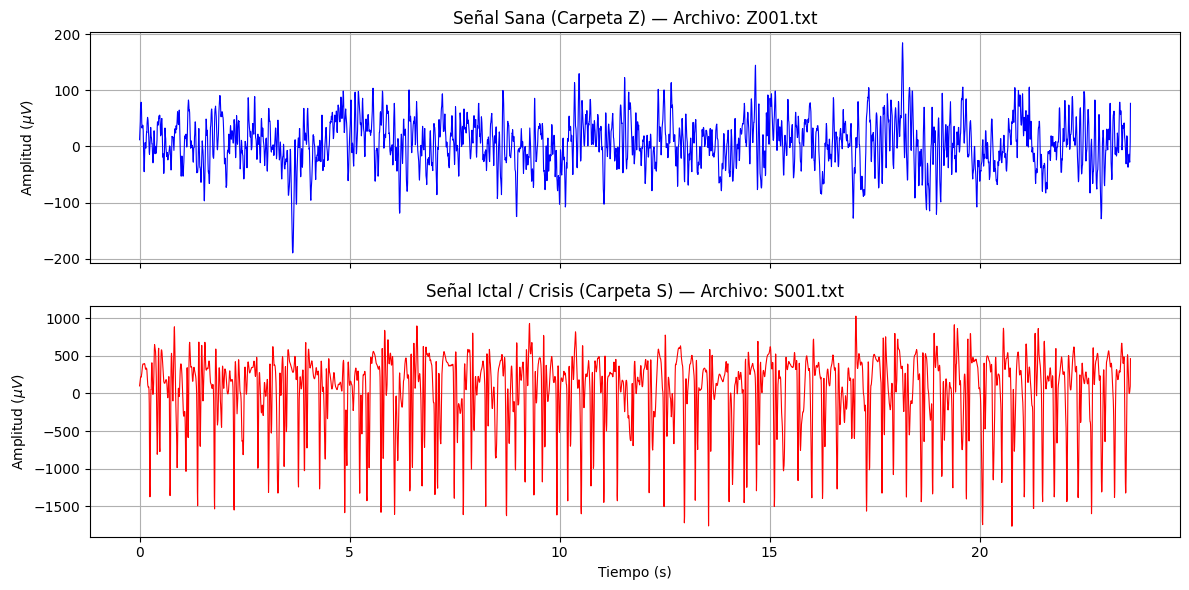

C:\Users\lorep\AppData\Local\Temp\ipykernel_4544\3970228196.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='clase', palette='viridis', order=df['clase'].value_counts().index)


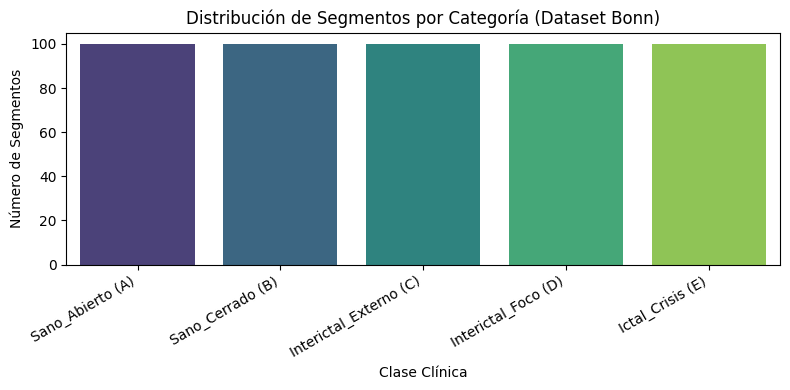

In [8]:

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

def plot_comparativa_clases(df, fs=173.61):
    """Genera la gráfica comparativa entre una señal sana y una ictal en el tiempo."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # Extraer una época de la carpeta Z (Sano) y otra de la S (Ictal)
    sano = df[df['carpeta_original'] == 'Z'].iloc[0]
    ictal = df[df['carpeta_original'] == 'S'].iloc[0]
    
    tiempo = np.arange(len(sano['senal'])) / fs
    
    axes[0].plot(tiempo, sano['senal'], color='blue', linewidth=0.8)
    axes[0].set_title(f"Señal Sana (Carpeta Z) — Archivo: {sano['archivo']}")
    axes[0].set_ylabel(r"Amplitud ($\mu V$)")
    axes[0].grid(True)
    
    axes[1].plot(tiempo, ictal['senal'], color='red', linewidth=0.8)
    axes[1].set_title(f"Señal Ictal / Crisis (Carpeta S) — Archivo: {ictal['archivo']}")
    axes[1].set_xlabel("Tiempo (s)")
    axes[1].set_ylabel(r"Amplitud ($\mu V$)")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_balance_clases(df):
    """Genera la gráfica de barras para el balance de clases."""
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='clase', palette='viridis', order=df['clase'].value_counts().index)
    plt.title("Distribución de Segmentos por Categoría (Dataset Bonn)")
    plt.xlabel("Clase Clínica")
    plt.ylabel("Número de Segmentos")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    
plot_comparativa_clases(df_eeg)
plot_balance_clases(df_eeg)    